# PyTorch 회귀 모델 실습: 의료비 예측

이 노트북은선형 회귀 실습을 **PyTorch 코드**로 구현한 구글 코랩용 실습 파일입니다.

## 실습 목표

1. 의료비 예측 데이터를 불러온다.
2. 데이터 구조, 요약 통계, 분포, 상관관계를 확인한다.
3. 범주형 변수를 숫자형 데이터로 변환한다.
4. PyTorch로 의료비 예측 회귀 모델을 만든다.
5. 기본 모델과 개선 모델을 비교한다.
6. 새 환자 데이터의 예상 의료비를 예측한다.

> 코드의 핵심 흐름  
> `read.csv()` → `summary()` → `cor()` → `lm()` → `summary()` → 변수 개선 → `predict()` → 실제값/예측값 비교

In [1]:
# ============================================================
# 1. 기본 라이브러리 불러오기
# ============================================================

# pandas는 표 형태의 데이터를 다루기 위한 라이브러리입니다.
# CSV 파일을 읽거나, 데이터프레임을 만들 때 사용합니다.
import pandas as pd

# numpy는 수치 계산을 위한 라이브러리입니다.
# 배열 계산, 평균, 표준편차, 제곱근 계산 등에 사용합니다.
import numpy as np

# matplotlib은 그래프를 그리기 위한 라이브러리입니다.
# 히스토그램, 산점도, 학습 손실 그래프 등을 그릴 때 사용합니다.
import matplotlib.pyplot as plt

# seaborn은 matplotlib 기반의 시각화 라이브러리입니다.
# 상관관계 히트맵, 산점도 행렬 등을 쉽게 그릴 수 있습니다.
import seaborn as sns

# torch는 PyTorch의 핵심 라이브러리입니다.
# Tensor 생성, 자동미분, 신경망 학습에 사용합니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 Adam, SGD 같은 최적화 알고리즘을 제공합니다.
import torch.optim as optim

# train_test_split은 데이터를 학습용/테스트용으로 나눌 때 사용합니다.
from sklearn.model_selection import train_test_split

# StandardScaler는 입력 변수의 평균을 0, 표준편차를 1로 맞추는 표준화 도구입니다.
from sklearn.preprocessing import StandardScaler

# 회귀 모델 평가 지표를 계산하기 위한 함수들입니다.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Colab에서 실행 결과를 동일하게 만들기 위해 난수를 고정합니다.
# 난수를 고정하면 매번 실행할 때 비슷한 결과를 얻을 수 있습니다.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 사용 가능한 경우 GPU를 사용하고, 아니면 CPU를 사용합니다.
# Colab 메뉴: 런타임 > 런타임 유형 변경 > GPU 선택 가능
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("현재 사용 장치:", device)

현재 사용 장치: cuda


In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================

# Colab에서는 파일 위치가 다를 수 있으므로 아래 순서로 데이터를 찾습니다.
# 1) /content/insurance_exp.csv
# 2) /content/data/insurance_exp.csv
# 3) 인터넷 공개 데이터셋 URL
#
# 직접 파일을 업로드하려면 Colab 왼쪽 파일 탭에 insurance_exp.csv를 업로드하면 됩니다.

from pathlib import Path

candidate_paths = [
    Path("/content/insurance_exp.csv"),
    Path("/content/data/insurance_exp.csv"),
    Path("insurance_exp.csv"),
    Path("data/insurance_exp.csv")
]

csv_path = None

# 후보 경로 중 실제 파일이 존재하는 경로를 찾습니다.
for path in candidate_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is not None:
    # 사용자가 업로드한 CSV 파일을 읽습니다.
    insurance_exp = pd.read_csv(csv_path)
    print("로컬 CSV 파일을 읽었습니다:", csv_path)
else:
    # 파일이 없으면 인터넷 공개 예제 데이터를 읽습니다.
    # 이 데이터는 의료비 예측 실습에 널리 사용되는 insurance 데이터셋입니다.
    url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
    insurance_exp = pd.read_csv(url)
    print("공개 URL에서 예제 데이터를 읽었습니다.")

    # 다음 실행 때도 같은 파일을 사용할 수 있도록 data 폴더에 저장합니다.
    insurance_exp.to_csv("data/insurance_exp.csv", index=False)

# 공개 데이터셋에서는 expenses 또는 charges로 되어 있을 수 있으므로 이름을 맞춥니다.
if "charges" in insurance_exp.columns:
    insurance_exp = insurance_exp.rename(columns={"charges": "expense"})

if "expenses" in insurance_exp.columns:
    insurance_exp = insurance_exp.rename(columns={"expenses": "expense"})

# 공개 데이터셋에서는 smoker, region이라는 이름을 사용할 수 있으므로 이름을 맞춥니다.
if "smoker" in insurance_exp.columns:
    insurance_exp = insurance_exp.rename(columns={"smoker": "smoking"})

if "region" in insurance_exp.columns:
    insurance_exp = insurance_exp.rename(columns={"region": "regions"})

# 데이터의 앞부분 5개 행을 출력하여 데이터가 잘 읽혔는지 확인합니다.
insurance_exp.head()

공개 URL에서 예제 데이터를 읽었습니다.


,age,sex,bmi,children,smoking,regions,expense
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# ============================================================
# 3. 데이터 구조 확인
# ============================================================

# 데이터프레임의 행과 열 개수를 확인합니다.
# 예: (1338, 7)은 1338행, 7열이라는 의미입니다.
print("데이터 크기:", insurance_exp.shape)

# 각 컬럼의 자료형과 결측치 여부를 확인합니다.
# object는 문자형 또는 범주형 데이터일 가능성이 높습니다.
insurance_exp.info()

# 수치형 데이터의 요약 통계를 확인합니다.
# count: 데이터 개수
# mean: 평균
# std: 표준편차
# min: 최솟값
# 25%, 50%, 75%: 사분위수
# max: 최댓값
insurance_exp.describe()

데이터 크기: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoking   1338 non-null   object 
 5   regions   1338 non-null   object 
 6   expense   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,expense
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
# ============================================================
# 4. 종속변수 expense 요약 통계 확인
# ============================================================

# expense는 예측하려는 대상값입니다.
# 즉, 의료보험으로 청구된 개인별 의료비입니다.
print("의료비 expense 요약 통계")
print(insurance_exp["expense"].describe())

# 평균과 중앙값을 따로 출력합니다.
# 평균이 중앙값보다 크면 오른쪽으로 긴 꼬리를 가진 분포일 가능성이 있습니다.
print("\n평균:", insurance_exp["expense"].mean())
print("중앙값:", insurance_exp["expense"].median())

의료비 expense 요약 통계
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: expense, dtype: float64

평균: 13270.422265141257
중앙값: 9382.033


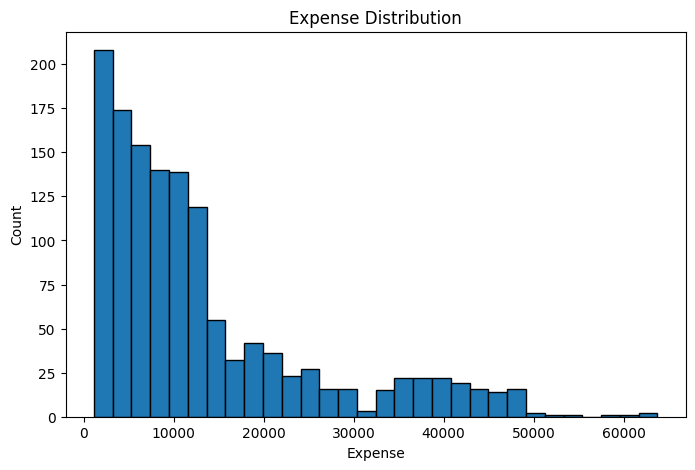

In [5]:
# ============================================================
# 5. 의료비 분포 히스토그램
# ============================================================

# 히스토그램은 데이터가 어떤 값에 많이 몰려 있는지 보여줍니다.
# 의료비 데이터는 일반적으로 오른쪽으로 긴 꼬리를 가집니다.
# 즉, 대부분은 낮거나 중간 의료비이지만 일부 사람은 매우 높은 의료비가 발생합니다.

plt.figure(figsize=(8, 5))

# bins는 막대 개수입니다.
plt.hist(insurance_exp["expense"], bins=30, edgecolor="black")

plt.title("Expense Distribution")
plt.xlabel("Expense")
plt.ylabel("Count")

plt.show()

In [6]:
# ============================================================
# 6. 범주형 변수 확인
# ============================================================

# 성별, 흡연 여부, 지역은 숫자가 아니라 문자로 표현된 범주형 변수입니다.
# 머신러닝 모델에 넣기 위해서는 나중에 숫자형으로 변환해야 합니다.

categorical_cols = []

# object 타입 컬럼은 보통 문자열/범주형 변수입니다.
for col in insurance_exp.columns:
    if insurance_exp[col].dtype == "object":
        categorical_cols.append(col)

print("범주형 컬럼:", categorical_cols)

# 각 범주형 컬럼의 값 개수를 확인합니다.
for col in categorical_cols:
    print("\n컬럼명:", col)
    print(insurance_exp[col].value_counts())

범주형 컬럼: ['sex', 'smoking', 'regions']

컬럼명: sex
sex
male      676
female    662
Name: count, dtype: int64

컬럼명: smoking
smoking
no     1064
yes     274
Name: count, dtype: int64

컬럼명: regions
regions
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [7]:
# ============================================================
# 7. 수치형 변수 간 상관관계 확인
# ============================================================

# 상관계수는 두 변수 사이의 관계 강도를 나타냅니다.
# 1에 가까우면 강한 양의 관계,
# -1에 가까우면 강한 음의 관계,
# 0에 가까우면 관계가 약하다는 의미입니다.

numeric_cols = ["age", "bmi", "children", "expense"]

correlation_matrix = insurance_exp[numeric_cols].corr()

print(correlation_matrix)

               age       bmi  children   expense
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
expense   0.299008  0.198341  0.067998  1.000000


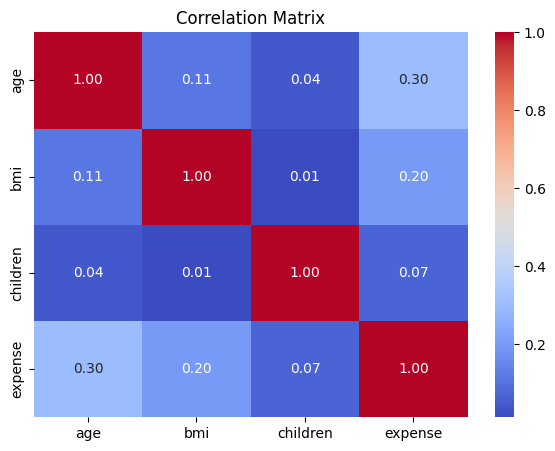

In [8]:
# ============================================================
# 8. 상관관계 히트맵 시각화
# ============================================================

# 히트맵은 상관관계를 색상으로 쉽게 확인할 수 있게 해줍니다.
# 값이 클수록 두 변수의 관계가 강합니다.

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,      # 각 칸에 숫자 표시
    fmt=".2f",       # 소수점 둘째 자리까지 표시
    cmap="coolwarm"  # 색상 팔레트
)

plt.title("Correlation Matrix")
plt.show()

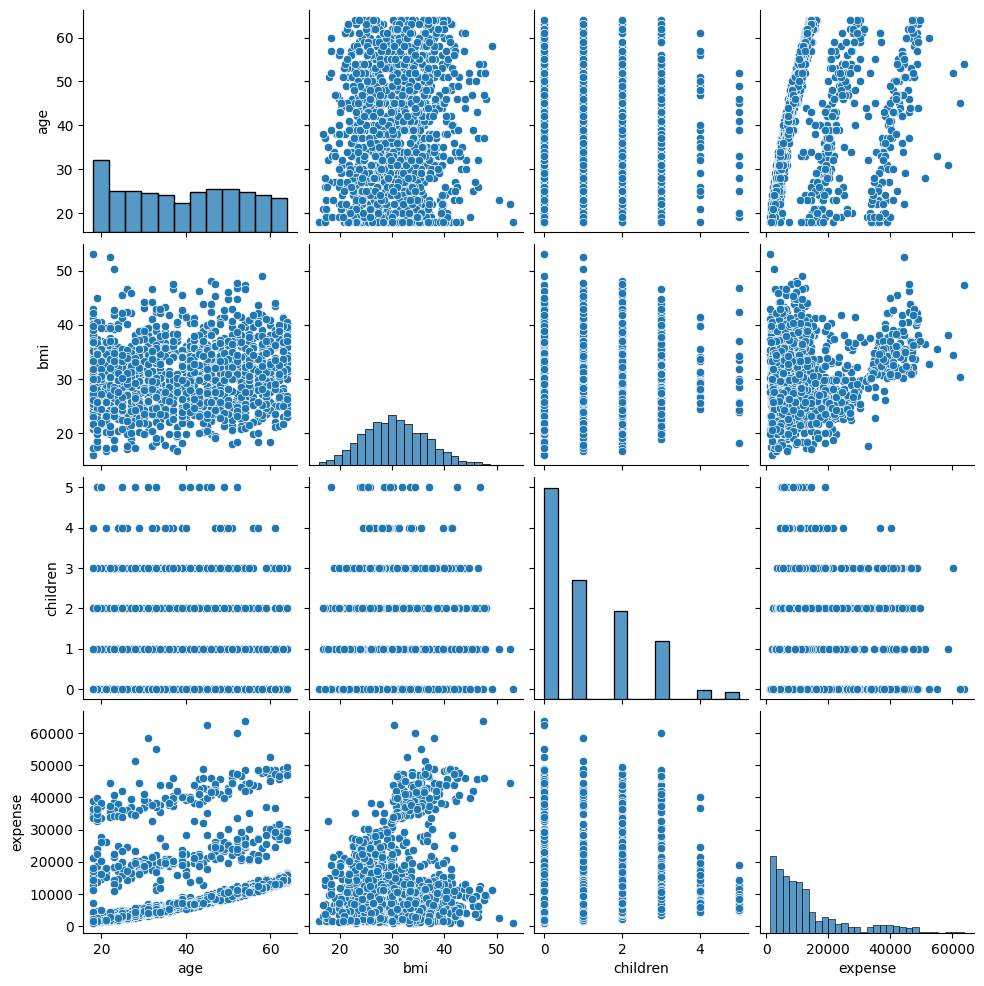

In [9]:
# ============================================================
# 9. 산점도 행렬 확인
# ============================================================

# 산점도 행렬은 여러 수치형 변수 간 관계를 한 번에 보여줍니다.
# 예를 들어 age와 expense가 함께 증가하는지,
# bmi와 expense가 어떤 관계인지 확인할 수 있습니다.

sns.pairplot(insurance_exp[numeric_cols])

plt.show()

In [10]:
# ============================================================
# 10. 기본 모델용 데이터 전처리
# ============================================================

# 기본 모델에서는 원본 변수만 사용합니다.
# 입력 변수 X와 정답 y를 분리합니다.
# X는 모델이 학습할 입력 데이터입니다.
# y는 모델이 맞혀야 하는 정답 의료비입니다.
X_basic = insurance_exp[["age", "children", "bmi", "sex", "smoking", "regions"]]
y = insurance_exp["expense"]

# get_dummies는 문자형 범주 변수를 0과 1로 변환합니다.
# 예: sex = male/female → sex_male 컬럼 생성
# drop_first=True는 기준 범주 하나를 제거하여 중복 정보를 줄입니다.
X_basic_encoded = pd.get_dummies(X_basic, drop_first=True)

print("변환 전 컬럼:")
print(X_basic.columns.tolist())

print("\n변환 후 컬럼:")
print(X_basic_encoded.columns.tolist())

X_basic_encoded.head()

변환 전 컬럼:
['age', 'children', 'bmi', 'sex', 'smoking', 'regions']

변환 후 컬럼:
['age', 'children', 'bmi', 'sex_male', 'smoking_yes', 'regions_northwest', 'regions_southeast', 'regions_southwest']


,age,children,bmi,sex_male,smoking_yes,regions_northwest,regions_southeast,regions_southwest
0,19,0,27.900,False,True,False,False,True
1,18,1,33.770,True,False,False,True,False
2,28,3,33.000,True,False,False,True,False
3,33,0,22.705,True,False,True,False,False
4,32,0,28.880,True,False,True,False,False


In [11]:
# ============================================================
# 11. 학습 데이터와 테스트 데이터 분리
# ============================================================

# 학습 데이터는 모델이 공부하는 데이터입니다.
# 테스트 데이터는 공부가 끝난 뒤 실력을 평가하는 데이터입니다.
#
# test_size=0.2는 전체 데이터 중 20%를 테스트용으로 사용한다는 의미입니다.
# random_state는 데이터를 나누는 방식을 고정하여 재현 가능하게 합니다.

X_train_basic, X_test_basic, y_train, y_test = train_test_split(
    X_basic_encoded,
    y,
    test_size=0.2,
    random_state=SEED
)

print("학습 입력 데이터 크기:", X_train_basic.shape)
print("테스트 입력 데이터 크기:", X_test_basic.shape)
print("학습 정답 데이터 크기:", y_train.shape)
print("테스트 정답 데이터 크기:", y_test.shape)

학습 입력 데이터 크기: (1070, 8)
테스트 입력 데이터 크기: (268, 8)
학습 정답 데이터 크기: (1070,)
테스트 정답 데이터 크기: (268,)


In [12]:
# ============================================================
# 12. 데이터 표준화
# ============================================================

# 신경망은 입력 변수들의 값 범위가 크게 다르면 학습이 불안정할 수 있습니다.
# 예를 들어 age는 10~60 정도이고, bmi는 15~50 정도입니다.
# 그래서 평균 0, 표준편차 1이 되도록 표준화합니다.
#
# 주의:
# 학습 데이터에는 fit_transform을 사용합니다.
# 테스트 데이터에는 transform만 사용합니다.
# 테스트 데이터로 평균과 표준편차를 다시 계산하면 데이터 누수 문제가 발생합니다.

x_scaler_basic = StandardScaler()

X_train_basic_scaled = x_scaler_basic.fit_transform(X_train_basic)
X_test_basic_scaled = x_scaler_basic.transform(X_test_basic)

# 정답 y도 표준화합니다.
# 의료비는 값의 범위가 크기 때문에 y를 표준화하면 신경망 학습이 더 안정적입니다.
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

print("X_train 표준화 후 평균:", X_train_basic_scaled.mean().round(4))
print("X_train 표준화 후 표준편차:", X_train_basic_scaled.std().round(4))

X_train 표준화 후 평균: -0.0
X_train 표준화 후 표준편차: 1.0


In [13]:
# ============================================================
# 13. NumPy 배열을 PyTorch Tensor로 변환
# ============================================================

# PyTorch 모델은 pandas DataFrame이나 NumPy 배열을 직접 학습하지 않습니다.
# Tensor라는 PyTorch 전용 자료형으로 변환해야 합니다.
#
# dtype=torch.float32는 신경망 학습에 적합한 실수형 자료형입니다.
# to(device)는 CPU 또는 GPU로 데이터를 이동시키는 코드입니다.

X_train_basic_tensor = torch.tensor(X_train_basic_scaled, dtype=torch.float32).to(device)
X_test_basic_tensor = torch.tensor(X_test_basic_scaled, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

print("X_train_basic_tensor 크기:", X_train_basic_tensor.shape)
print("y_train_tensor 크기:", y_train_tensor.shape)

X_train_basic_tensor 크기: torch.Size([1070, 8])
y_train_tensor 크기: torch.Size([1070, 1])


In [14]:
# ============================================================
# 14. PyTorch 회귀 모델 클래스 정의
# ============================================================

# nn.Module은 PyTorch에서 신경망 모델을 만들 때 상속하는 기본 클래스입니다.
# 이 모델은 선형회귀를 확장한 간단한 신경망 회귀 모델입니다.
#
# 구조:
# 입력층 → 은닉층1 → ReLU → 은닉층2 → ReLU → 출력층
#
# 출력층은 의료비 예측값 1개를 출력하므로 마지막 출력 크기는 1입니다.

class ExpenseRegressionModel(nn.Module):
    def __init__(self, input_dim):
        # 부모 클래스 nn.Module의 초기화 기능을 실행합니다.
        super().__init__()

        # 첫 번째 완전연결층입니다.
        # input_dim개의 입력 변수를 받아 64개의 값을 출력합니다.
        self.fc1 = nn.Linear(input_dim, 64)

        # 두 번째 완전연결층입니다.
        # 64개의 값을 받아 32개의 값을 출력합니다.
        self.fc2 = nn.Linear(64, 32)

        # 마지막 출력층입니다.
        # 32개의 값을 받아 의료비 예측값 1개를 출력합니다.
        self.fc3 = nn.Linear(32, 1)

        # ReLU 활성함수입니다.
        # 음수는 0으로 만들고 양수는 그대로 통과시킵니다.
        # 신경망이 비선형 관계를 학습할 수 있도록 도와줍니다.
        self.relu = nn.ReLU()

    def forward(self, x):
        # 입력 데이터를 첫 번째 층에 통과시킵니다.
        x = self.fc1(x)

        # 첫 번째 층의 결과에 ReLU 활성함수를 적용합니다.
        x = self.relu(x)

        # 두 번째 층에 통과시킵니다.
        x = self.fc2(x)

        # 두 번째 층의 결과에 ReLU 활성함수를 적용합니다.
        x = self.relu(x)

        # 마지막 출력층에서 최종 예측값을 계산합니다.
        x = self.fc3(x)

        # 최종 예측값을 반환합니다.
        return x

In [15]:
# ============================================================
# 15. 모델 학습 함수 정의
# ============================================================

# 같은 학습 코드를 기본 모델과 개선 모델에 반복해서 사용할 수 있도록 함수로 만듭니다.

def train_model(X_train_tensor, y_train_tensor, input_dim, epochs=1000, lr=0.001):
    # 모델 객체를 생성합니다.
    model = ExpenseRegressionModel(input_dim=input_dim).to(device)

    # MSELoss는 회귀 문제에서 많이 사용하는 손실 함수입니다.
    # 예측값과 실제값 차이를 제곱한 뒤 평균을 계산합니다.
    criterion = nn.MSELoss()

    # Adam은 많이 사용하는 최적화 알고리즘입니다.
    # 모델의 가중치를 손실값이 줄어드는 방향으로 자동 수정합니다.
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # epoch별 손실값을 저장할 리스트입니다.
    loss_history = []

    # 지정한 epoch 수만큼 반복 학습합니다.
    for epoch in range(epochs):
        # 모델을 학습 모드로 설정합니다.
        model.train()

        # 이전 epoch에서 계산된 기울기를 초기화합니다.
        # PyTorch는 기본적으로 기울기를 누적하므로 매번 초기화해야 합니다.
        optimizer.zero_grad()

        # 앞먹임 단계입니다.
        # 입력 데이터를 모델에 넣어 예측값을 계산합니다.
        predictions = model(X_train_tensor)

        # 손실값을 계산합니다.
        # 예측값과 실제 정답값이 얼마나 다른지 계산합니다.
        loss = criterion(predictions, y_train_tensor)

        # 역전파 단계입니다.
        # 손실값을 기준으로 각 가중치의 기울기를 계산합니다.
        loss.backward()

        # 가중치 업데이트 단계입니다.
        # 계산된 기울기를 이용하여 모델 파라미터를 수정합니다.
        optimizer.step()

        # 현재 손실값을 리스트에 저장합니다.
        loss_history.append(loss.item())

        # 100 epoch마다 학습 상황을 출력합니다.
        if (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

    # 학습된 모델과 손실 기록을 반환합니다.
    return model, loss_history

In [16]:
# ============================================================
# 16. 기본 모델 학습
# ============================================================

# 입력 변수 개수를 확인합니다.
input_dim_basic = X_train_basic_tensor.shape[1]

# 기본 모델을 학습합니다.
basic_model, basic_loss_history = train_model(
    X_train_tensor=X_train_basic_tensor,
    y_train_tensor=y_train_tensor,
    input_dim=input_dim_basic,
    epochs=1000,
    lr=0.001
)

Epoch [100/1000], Loss: 0.167699
Epoch [200/1000], Loss: 0.134810
Epoch [300/1000], Loss: 0.122108
Epoch [400/1000], Loss: 0.112038
Epoch [500/1000], Loss: 0.102482
Epoch [600/1000], Loss: 0.093994
Epoch [700/1000], Loss: 0.086165
Epoch [800/1000], Loss: 0.079331
Epoch [900/1000], Loss: 0.073662
Epoch [1000/1000], Loss: 0.068805


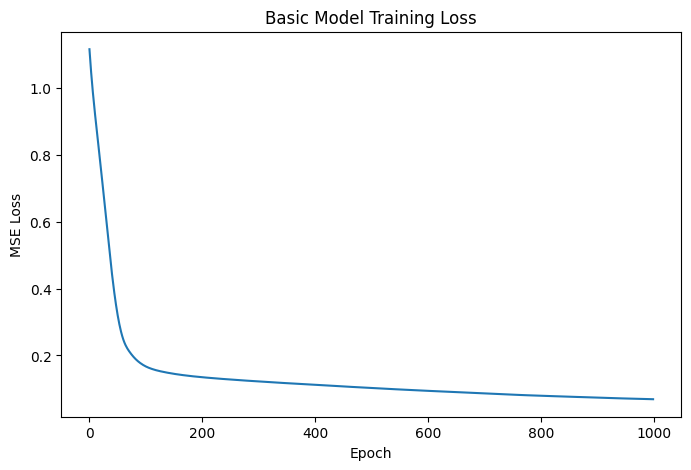

In [17]:
# ============================================================
# 17. 손실값 그래프 확인
# ============================================================

# 손실값이 점점 감소하면 모델이 정상적으로 학습되고 있다는 뜻입니다.

plt.figure(figsize=(8, 5))

plt.plot(basic_loss_history)

plt.title("Basic Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.show()

In [18]:
# ============================================================
# 18. 회귀 모델 평가 함수 정의
# ============================================================

# 모델 평가를 반복해서 사용할 수 있도록 함수로 만듭니다.

def evaluate_model(model, X_test_tensor, y_test_original, y_scaler, title="Model"):
    # 모델을 평가 모드로 전환합니다.
    # 평가 모드에서는 Dropout, BatchNorm 등이 학습 방식과 다르게 동작합니다.
    model.eval()

    # 평가할 때는 기울기 계산이 필요 없습니다.
    # torch.no_grad()를 사용하면 메모리 사용량이 줄고 계산이 빨라집니다.
    with torch.no_grad():
        # 표준화된 예측값을 계산합니다.
        pred_scaled = model(X_test_tensor)

    # GPU Tensor일 수 있으므로 CPU로 옮긴 뒤 NumPy 배열로 변환합니다.
    pred_scaled_np = pred_scaled.cpu().numpy()

    # 예측값은 y 표준화가 적용된 값입니다.
    # 실제 의료비 단위로 해석하기 위해 inverse_transform으로 원래 단위로 되돌립니다.
    pred_original = y_scaler.inverse_transform(pred_scaled_np).reshape(-1)

    # 실제값도 NumPy 배열로 변환합니다.
    y_true = np.array(y_test_original)

    # 평가 지표를 계산합니다.
    mae = mean_absolute_error(y_true, pred_original)
    mse = mean_squared_error(y_true, pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, pred_original)

    # 실제값과 예측값 사이의 상관계수를 계산합니다.
    corr = np.corrcoef(y_true, pred_original)[0, 1]

    print(f"========== {title} 평가 결과 ==========")
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")
    print(f"Corr : {corr:.4f}")

    # 결과를 딕셔너리로 반환합니다.
    return {
        "prediction": pred_original,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Corr": corr
    }

In [19]:
# ============================================================
# 19. 기본 모델 성능 평가
# ============================================================

basic_result = evaluate_model(
    model=basic_model,
    X_test_tensor=X_test_basic_tensor,
    y_test_original=y_test,
    y_scaler=y_scaler,
    title="Basic PyTorch Regression Model"
)

========== Basic PyTorch Regression Model 평가 결과 ==========
MAE  : 3307.04
MSE  : 30668512.40
RMSE : 5537.92
R2   : 0.8025
Corr : 0.8982


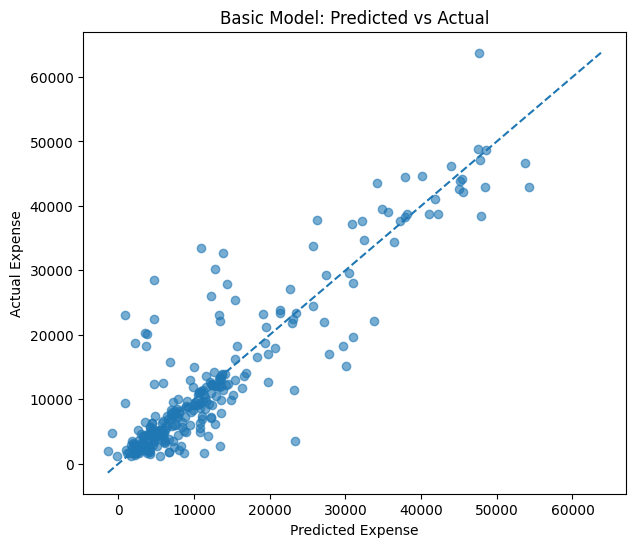

In [20]:
# ============================================================
# 20. 실제값과 예측값 시각화
# ============================================================

# x축: 모델이 예측한 의료비
# y축: 실제 의료비
# 점들이 대각선에 가까울수록 예측이 정확합니다.

plt.figure(figsize=(7, 6))

plt.scatter(basic_result["prediction"], y_test, alpha=0.6)

# 대각선 기준선을 그립니다.
# 이 선은 예측값과 실제값이 완전히 같은 위치를 의미합니다.
min_value = min(basic_result["prediction"].min(), y_test.min())
max_value = max(basic_result["prediction"].max(), y_test.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title("Basic Model: Predicted vs Actual")
plt.xlabel("Predicted Expense")
plt.ylabel("Actual Expense")

plt.show()

In [21]:
# ============================================================
# 21. 개선 모델용 변수 생성
# ============================================================

# 개선 내용:
# 1) age_2 = age^2
# 2) bmi33 = bmi >= 33이면 1, 아니면 0
# 3) bmi33 * smoking 상호작용 효과 추가

insurance_exp_improved = insurance_exp.copy()

# 나이의 제곱 변수를 추가합니다.
# 나이와 의료비의 관계가 완전한 직선이 아닐 수 있으므로 비선형 효과를 반영합니다.
insurance_exp_improved["age_2"] = insurance_exp_improved["age"] ** 2

# BMI가 33 이상이면 1, 아니면 0으로 표시하는 비만 여부 변수를 만듭니다.
insurance_exp_improved["bmi33"] = np.where(insurance_exp_improved["bmi"] >= 33, 1, 0)

# 개선 모델에 사용할 입력 변수입니다.
X_improved = insurance_exp_improved[
    ["age", "age_2", "children", "bmi", "sex", "bmi33", "smoking", "regions"]
]

# 범주형 변수를 원-핫 인코딩합니다.
X_improved_encoded = pd.get_dummies(X_improved, drop_first=True)

print("개선 모델 입력 컬럼:")
print(X_improved_encoded.columns.tolist())

X_improved_encoded.head()

개선 모델 입력 컬럼:
['age', 'age_2', 'children', 'bmi', 'bmi33', 'sex_male', 'smoking_yes', 'regions_northwest', 'regions_southeast', 'regions_southwest']


,age,age_2,children,bmi,bmi33,sex_male,smoking_yes,regions_northwest,regions_southeast,regions_southwest
0,19,361,0,27.900,0,False,True,False,False,True
1,18,324,1,33.770,1,True,False,False,True,False
2,28,784,3,33.000,1,True,False,False,True,False
3,33,1089,0,22.705,0,True,False,True,False,False
4,32,1024,0,28.880,0,True,False,True,False,False


In [22]:
# ============================================================
# 22. 개선 모델 데이터 분리 및 표준화
# ============================================================

# 기본 모델과 같은 y를 사용합니다.
# 같은 random_state를 사용하여 비교가 가능하도록 합니다.

X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(
    X_improved_encoded,
    y,
    test_size=0.2,
    random_state=SEED
)

# 개선 모델용 입력 데이터 표준화 객체입니다.
x_scaler_improved = StandardScaler()

X_train_improved_scaled = x_scaler_improved.fit_transform(X_train_improved)
X_test_improved_scaled = x_scaler_improved.transform(X_test_improved)

# y는 기본 모델에서 사용한 y_scaler와 동일하게 새로 맞춰도 됩니다.
# 여기서는 학습 데이터가 동일한 분할이므로 다시 생성해도 같은 방식입니다.
y_scaler_improved = StandardScaler()

y_train_improved_scaled = y_scaler_improved.fit_transform(y_train_improved.values.reshape(-1, 1))
y_test_improved_scaled = y_scaler_improved.transform(y_test_improved.values.reshape(-1, 1))

# PyTorch Tensor로 변환합니다.
X_train_improved_tensor = torch.tensor(X_train_improved_scaled, dtype=torch.float32).to(device)
X_test_improved_tensor = torch.tensor(X_test_improved_scaled, dtype=torch.float32).to(device)

y_train_improved_tensor = torch.tensor(y_train_improved_scaled, dtype=torch.float32).to(device)
y_test_improved_tensor = torch.tensor(y_test_improved_scaled, dtype=torch.float32).to(device)

print("개선 모델 학습 데이터 크기:", X_train_improved_tensor.shape)

개선 모델 학습 데이터 크기: torch.Size([1070, 10])


In [23]:
# ============================================================
# 23. 개선 모델 학습
# ============================================================

input_dim_improved = X_train_improved_tensor.shape[1]

improved_model, improved_loss_history = train_model(
    X_train_tensor=X_train_improved_tensor,
    y_train_tensor=y_train_improved_tensor,
    input_dim=input_dim_improved,
    epochs=1000,
    lr=0.001
)

Epoch [100/1000], Loss: 0.159694
Epoch [200/1000], Loss: 0.136504
Epoch [300/1000], Loss: 0.122908
Epoch [400/1000], Loss: 0.110898
Epoch [500/1000], Loss: 0.100123
Epoch [600/1000], Loss: 0.091009
Epoch [700/1000], Loss: 0.083081
Epoch [800/1000], Loss: 0.076657
Epoch [900/1000], Loss: 0.071270
Epoch [1000/1000], Loss: 0.066668


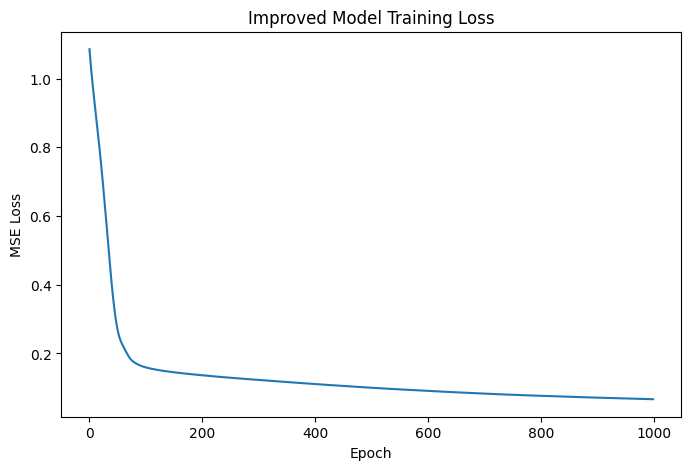

In [24]:
# ============================================================
# 24. 개선 모델 손실 그래프
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(improved_loss_history)

plt.title("Improved Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.show()

In [25]:
# ============================================================
# 25. 개선 모델 성능 평가
# ============================================================

improved_result = evaluate_model(
    model=improved_model,
    X_test_tensor=X_test_improved_tensor,
    y_test_original=y_test_improved,
    y_scaler=y_scaler_improved,
    title="Improved PyTorch Regression Model"
)

========== Improved PyTorch Regression Model 평가 결과 ==========
MAE  : 3171.78
MSE  : 25701924.50
RMSE : 5069.71
R2   : 0.8344
Corr : 0.9147


In [26]:
# ============================================================
# 26. 기본 모델과 개선 모델 성능 비교
# ============================================================

comparison = pd.DataFrame({
    "Model": ["Basic Model", "Improved Model"],
    "MAE": [basic_result["MAE"], improved_result["MAE"]],
    "RMSE": [basic_result["RMSE"], improved_result["RMSE"]],
    "R2": [basic_result["R2"], improved_result["R2"]],
    "Correlation": [basic_result["Corr"], improved_result["Corr"]]
})

comparison

,Model,MAE,RMSE,R2,Correlation
0,Basic Model,3307.039062,5537.91589,0.802456,0.898175
1,Improved Model,3171.783490,5069.70655,0.834447,0.914743


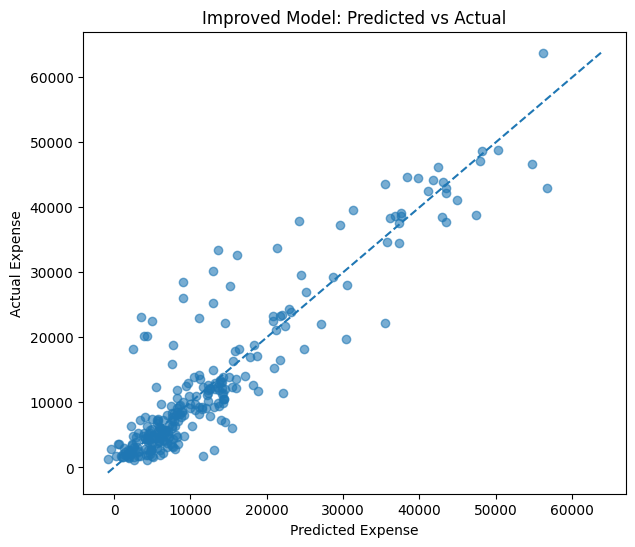

In [27]:
# ============================================================
# 27. 개선 모델 실제값과 예측값 시각화
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(improved_result["prediction"], y_test_improved, alpha=0.6)

min_value = min(improved_result["prediction"].min(), y_test_improved.min())
max_value = max(improved_result["prediction"].max(), y_test_improved.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title("Improved Model: Predicted vs Actual")
plt.xlabel("Predicted Expense")
plt.ylabel("Actual Expense")

plt.show()

In [28]:
# ============================================================
# 28. 새 환자 데이터 예측 함수 만들기
# ============================================================

# predict()로 새 환자의 의료비를 예측했습니다.
# 주의:
# 새 데이터도 학습 데이터와 같은 전처리 과정을 거쳐야 합니다.
# 즉, age_2 생성, bmi33 생성, 원-핫 인코딩, 컬럼 순서 맞춤, 표준화가 필요합니다.

def predict_new_patient(model, patient_dict, train_columns, x_scaler, y_scaler):
    # 딕셔너리 형태의 새 환자 정보를 데이터프레임으로 변환합니다.
    patient_df = pd.DataFrame([patient_dict])

    # 개선 모델에서 사용한 파생 변수를 똑같이 생성합니다.
    patient_df["age_2"] = patient_df["age"] ** 2
    patient_df["bmi33"] = np.where(patient_df["bmi"] >= 33, 1, 0)

    # 개선 모델에서 사용한 컬럼 순서로 정리합니다.
    patient_df = patient_df[
        ["age", "age_2", "children", "bmi", "sex", "bmi33", "smoking", "regions"]
    ]

    # 범주형 변수를 원-핫 인코딩합니다.
    patient_encoded = pd.get_dummies(patient_df, drop_first=True)

    # 학습 데이터에 있던 컬럼과 새 데이터의 컬럼을 맞춥니다.
    # 새 데이터에 없는 컬럼은 0으로 채웁니다.
    patient_encoded = patient_encoded.reindex(columns=train_columns, fill_value=0)

    # 학습 데이터 기준으로 표준화합니다.
    patient_scaled = x_scaler.transform(patient_encoded)

    # PyTorch Tensor로 변환합니다.
    patient_tensor = torch.tensor(patient_scaled, dtype=torch.float32).to(device)

    # 모델을 평가 모드로 설정합니다.
    model.eval()

    # 새 데이터 예측에는 기울기 계산이 필요 없습니다.
    with torch.no_grad():
        pred_scaled = model(patient_tensor)

    # 표준화된 예측값을 실제 의료비 단위로 되돌립니다.
    pred_original = y_scaler.inverse_transform(pred_scaled.cpu().numpy())

    # 숫자 하나만 반환합니다.
    return pred_original[0][0]

In [29]:
# ============================================================
# 29. 새 환자 의료비 예측
# ============================================================

# 코드 예시 1:
# 33세, BMI 33, 자녀 2명, 남성, 비흡연, northeast 지역

patient_1 = {
    "age": 33,
    "children": 2,
    "bmi": 33,
    "sex": "male",
    "smoking": "no",
    "regions": "northeast"
}

pred_1 = predict_new_patient(
    model=improved_model,
    patient_dict=patient_1,
    train_columns=X_improved_encoded.columns,
    x_scaler=x_scaler_improved,
    y_scaler=y_scaler_improved
)

print("환자 1 예상 의료비:", round(pred_1, 2))

환자 1 예상 의료비: 7841.67


In [30]:
# ============================================================
# 30. 추가 환자 예측 예시
# ============================================================

# 코드 예시 2:
# 33세, BMI 33, 자녀 2명, 여성, 비흡연, northeast 지역

patient_2 = {
    "age": 33,
    "children": 2,
    "bmi": 33,
    "sex": "female",
    "smoking": "no",
    "regions": "northeast"
}

pred_2 = predict_new_patient(
    model=improved_model,
    patient_dict=patient_2,
    train_columns=X_improved_encoded.columns,
    x_scaler=x_scaler_improved,
    y_scaler=y_scaler_improved
)

print("환자 2 예상 의료비:", round(pred_2, 2))


# 코드 예시 3:
# 33세, BMI 33, 자녀 0명, 여성, 비흡연, northeast 지역

patient_3 = {
    "age": 33,
    "children": 0,
    "bmi": 33,
    "sex": "female",
    "smoking": "no",
    "regions": "northeast"
}

pred_3 = predict_new_patient(
    model=improved_model,
    patient_dict=patient_3,
    train_columns=X_improved_encoded.columns,
    x_scaler=x_scaler_improved,
    y_scaler=y_scaler_improved
)

print("환자 3 예상 의료비:", round(pred_3, 2))

환자 2 예상 의료비: 7841.67
환자 3 예상 의료비: 6770.11


# 실습 정리

## 1. 핵심 개념

- 회귀는 숫자를 예측하는 머신러닝 방법입니다.
- 의료비 예측에서는 `expense`가 종속변수입니다.
- `age`, `bmi`, `children`, `sex`, `smoking`, `regions`는 독립변수입니다.
- 범주형 변수는 반드시 숫자형으로 변환해야 합니다.
- PyTorch 모델 학습은 다음 순서로 진행됩니다.

```text
데이터 준비
↓
전처리
↓
Tensor 변환
↓
모델 정의
↓
손실 함수 정의
↓
최적화 알고리즘 정의
↓
학습 반복
↓
평가
↓
새 데이터 예측
```

## 3. 성능 개선 아이디어

다음 변수를 추가하면 모델 성능 향상에 도움이 될 수 있습니다.

- `age_2`: 나이의 비선형 영향 반영
- `bmi33`: BMI 33 이상 비만 여부 반영
- `bmi33 * smoking`: 비만과 흡연의 상호작용 효과 반영

PyTorch에서는 이러한 변수를 직접 추가한 뒤 신경망 모델에 입력하여 학습할 수 있습니다.